## Library Import

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# encoding , scaling
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# split data
from sklearn.model_selection import train_test_split, GridSearchCV

# models
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

# evaluation
from sklearn.metrics import mean_squared_error


# **1- DATA EXPLORATION** - khaled

In [4]:
# reading data
df = pd.read_csv(r"../dataset/medical-cost-personal-dataset.csv")

In [5]:
# data exploration 
df.head()

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,1984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065 entries, 0 to 1064
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1065 non-null   int64  
 1   gender    1065 non-null   object 
 2   bmi       1047 non-null   float64
 3   children  1065 non-null   int64  
 4   smoker    1065 non-null   object 
 5   region    1065 non-null   object 
 6   charges   1065 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 58.4+ KB


In [7]:
# values
print(df['gender'].unique())
print(df['smoker'].unique())
print(df['region'].unique())

['female' 'male']
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast']


# **2- DATA PREPROCESSING** - mostafa

In [8]:
# checking for duplicate rows
print(df.duplicated().sum())

# drop dublicates
df = df.drop_duplicates()

1


In [9]:
# check the missing values
df.isnull().sum()

age          0
gender       0
bmi         18
children     0
smoker       0
region       0
charges      0
dtype: int64

In [10]:
# handeling missing values <in the target>   -- fill it eith the median
df['bmi'].fillna(df['bmi'].mean(), inplace=True)
# check the result of handeled values
df.isnull().sum()

/var/folders/cg/0bkbk_zs637gjlj7n5dmkhqr0000gn/T/ipykernel_46648/3755556739.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].mean(), inplace=True)


age         0
gender      0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
# target selecting
target = 'charges'

In [12]:
df.head()

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,1984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [13]:
# categorical feature selecting
feature_cols = ['gender', 'smoker', 'region']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [14]:
# encoding categorical features & defining numerical featurs
X_cat = encoder.fit_transform(df[feature_cols])
X_num = df[['age', 'children', 'bmi']] 

In [15]:
# X & Y matrices

# merging cat with num data in featur matrix 
X = np.hstack([pd.DataFrame(X_num).values, X_cat]) # feature matrix     --- hstack : horizontal stack <nums at left , one hot at right>
# target
y = df[target] # target vector

In [16]:
# X check
pd.DataFrame(X).head()

,0,1,2,3,4,5,6,7,8,9,10
0,19.0,0.0,27.900,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,18.0,1.0,33.770,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,28.0,3.0,33.000,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,33.0,0.0,22.705,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,32.0,0.0,28.880,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [17]:
# split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=50,
                                                    shuffle=True
                                                    )


In [18]:
# scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **3- TRAINING MODEL** - khaled

## 3.a- KNN MODEL

In [19]:
# finding best k
knn = KNeighborsRegressor(weights='distance')   # gives more importance to closer neighbors

param_grid = {'n_neighbors': np.arange(1,30)}
knn_gscv = GridSearchCV(knn, param_grid, cv=5, scoring='neg_mean_squared_error') # cv: folds nomber in cross validation, 4 train 1 test 5 times, reduce overfitting. so we don't need validation set

In [20]:
# KNN

# train the model
knn_gscv.fit(X_train, y_train)
# predict y
y_pred_knn = knn_gscv.predict(X_test) 

## 3.b- LINEAR REGRESSION MODEL

In [21]:
# Linear Regression

# train the model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# predict y
y_pred = regressor.predict(X_test)


/Users/gamal/Projects/MachineLearningProject/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/gamal/Projects/MachineLearningProject/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/gamal/Projects/MachineLearningProject/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


# **4- EVALUATION** - doha

## Graphs for KNN

In [22]:
pd.DataFrame({'y_test': y_test[:10].round(2), 'y_pred': y_pred_knn[:10].round(2)})

,y_test,y_pred
183,9225.26,8918.07
988,3238.44,2858.70
550,3500.61,4384.93
760,7160.09,7400.97
516,10579.71,11032.62
9,2721.32,2584.11
997,1241.56,1392.26
243,8835.26,9845.94
483,4435.09,4520.38
790,8410.05,9018.76


In [23]:
mse = mean_squared_error(y_test, y_pred_knn)  # 1/n * sum (y_true - y_pred)^2
rmse = np.sqrt(mse)

print("MSE :", mse)
print("RMSE:", rmse)

MSE : 4229500.070806524
RMSE: 2056.5748395831656


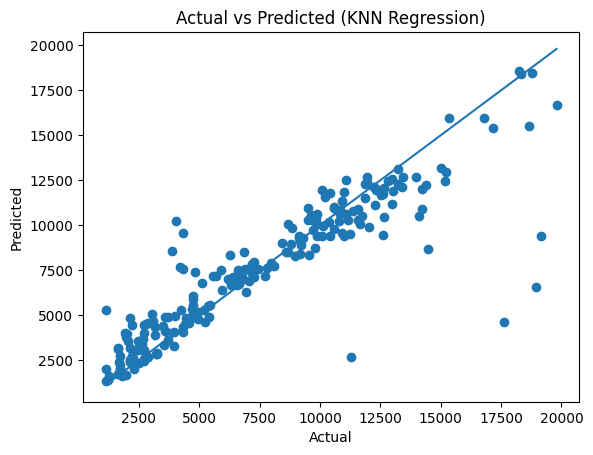

In [24]:
plt.scatter(y_test, y_pred_knn)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (KNN Regression)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()]) # point1 = [y_test.min(), y_test.min()], point2 = [y_test.max(), y_test.max()]

plt.show()

## Graphs for LR

In [25]:
# check y_test & y_pred
pd.DataFrame({'y_test': y_test[:10].round(2), 'y_pred': y_pred[:10].round(2)})

,y_test,y_pred
183,9225.26,9708.83
988,3238.44,4610.02
550,3500.61,4492.02
760,7160.09,8152.92
516,10579.71,11158.54
9,2721.32,3526.49
997,1241.56,958.50
243,8835.26,9548.72
483,4435.09,5256.10
790,8410.05,9256.41


In [26]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE :", mse)
print("RMSE:", rmse)

MSE : 3591045.7493999857
RMSE: 1895.0054747678134


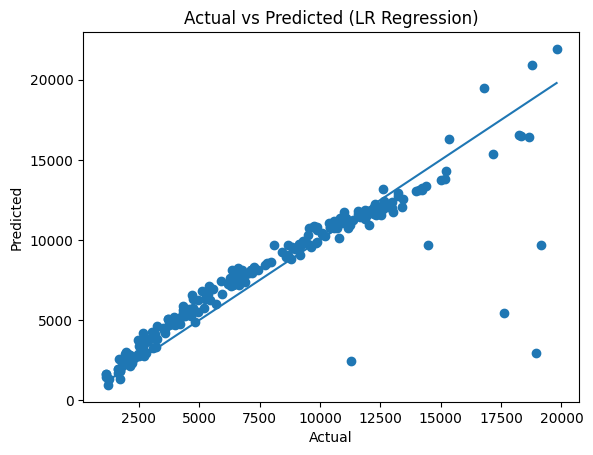

In [27]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (LR Regression)")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()